<a href="https://colab.research.google.com/github/useanynoms-commits/IDRA/blob/main/Assignment_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Student Wellbeing Statistical Analysis & Probability
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('Day16_Student_Wellbeing_Survey.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nInfo:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSummary:")
print(df.describe())

Shape: (600, 20)

First 5 rows:
  Student_ID  Age        Faculty  Year_of_Study        City     Accommodation  \
0    STU0001   21   Data Science              3   Bengaluru            Hostel   
1    STU0002   21   Data Science              4        Pune            Hostel   
2    STU0003   22  Life Sciences              2  Chandigarh              Home   
3    STU0004   18       Business              4   Bengaluru            Hostel   
4    STU0005   20       Business              3       Jammu  Shared Apartment   

  Scholarship Part_Time_Job Internet_Quality Preferred_Study_Space  \
0          No           Yes             Good                  Café   
1         Yes            No             Poor               Library   
2         Yes            No             Poor                  Home   
3         Yes           Yes          Average                  Café   
4         Yes            No             Good                  Home   

   Weekly_Study_Hours  Average_Sleep_Hours  Daily_Screen_Tim

In [4]:
"""
Step 2: Mean, Median, Mode
"""
cols = ['Weekly_Study_Hours', 'Average_Sleep_Hours', 'Daily_Screen_Time_Hours',
        'Stress_Score', 'Academic_Readiness_Score']

summary = pd.DataFrame({
    'Mean':   df[cols].mean(),
    'Median': df[cols].median(),
    'Mode':   df[cols].mode().iloc[0]
}).round(3)

print(summary)

                            Mean  Median  Mode
Weekly_Study_Hours        15.691   15.40  13.1
Average_Sleep_Hours        6.998    7.00   7.0
Daily_Screen_Time_Hours    4.503    4.20   3.5
Stress_Score               4.464    4.50   4.7
Academic_Readiness_Score  71.773   71.65  71.1


In [5]:
"""
Step 3: Dispersion Measures & Variability
"""
cols = ['Weekly_Study_Hours', 'Average_Sleep_Hours', 'Daily_Screen_Time_Hours',
        'Stress_Score', 'Academic_Readiness_Score']

disp = pd.DataFrame({
    'Range':    df[cols].max() - df[cols].min(),
    'Variance': df[cols].var(),
    'Std_Dev':  df[cols].std(),
    'Q1':       df[cols].quantile(0.25),
    'Q3':       df[cols].quantile(0.75),
    'IQR':      df[cols].quantile(0.75) - df[cols].quantile(0.25)
}).round(3)
print(disp)
# Coefficient of Variation for fair comparison across different scales
cv = (df[cols].std() / df[cols].mean() * 100).round(2)
print("\nCoefficient of Variation (%):")
print(cv)
print(f"\nGreatest Variability: {cv.idxmax()} (CV = {cv.max()}%)")

                          Range  Variance  Std_Dev      Q1      Q3     IQR
Weekly_Study_Hours         30.0    19.217    4.384  13.000  18.425   5.425
Average_Sleep_Hours         5.0     0.703    0.839   6.475   7.600   1.125
Daily_Screen_Time_Hours    11.2     3.469    1.863   3.200   5.400   2.200
Stress_Score                8.4     2.782    1.668   3.300   5.700   2.400
Academic_Readiness_Score   56.1    93.982    9.694  65.200  78.025  12.825

Coefficient of Variation (%):
Weekly_Study_Hours          27.94
Average_Sleep_Hours         11.99
Daily_Screen_Time_Hours     41.36
Stress_Score                37.36
Academic_Readiness_Score    13.51
dtype: float64

Greatest Variability: Daily_Screen_Time_Hours (CV = 41.36%)


In [6]:
"""
Step 4: Outlier Detection using IQR Method
"""
outlier_cols = ['Weekly_Study_Hours', 'Daily_Screen_Time_Hours',
                'Commute_Time_Minutes', 'Monthly_Discretionary_Spending']

report = []
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    report.append({
        'Variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
        'IQR': round(IQR, 2), 'Lower_Bound': round(lower, 2),
        'Upper_Bound': round(upper, 2), 'Outlier_Count': n_out,
        'Outlier_%': round(n_out / len(df) * 100, 2)
    })

print(pd.DataFrame(report))

                         Variable       Q1       Q3      IQR  Lower_Bound  \
0              Weekly_Study_Hours    13.00    18.42     5.42         4.86   
1         Daily_Screen_Time_Hours     3.20     5.40     2.20        -0.10   
2            Commute_Time_Minutes    13.38    31.52    18.15       -13.85   
3  Monthly_Discretionary_Spending  4113.00  7808.50  3695.50     -1430.25   

   Upper_Bound  Outlier_Count  Outlier_%  
0        26.56              8       1.33  
1         8.70             18       3.00  
2        58.75              4       0.67  
3     13351.75             20       3.33  


In [7]:
"""
Step 5: Mean vs Median Before & After Outlier Removal
(Variable: Monthly_Discretionary_Spending - has highest outlier count)
"""
col = 'Monthly_Discretionary_Spending'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df[col] >= lower) & (df[col] <= upper)]

comparison = pd.DataFrame({
    'Before_Removal': [round(df[col].mean(), 2), round(df[col].median(), 2), len(df)],
    'After_Removal':  [round(df_clean[col].mean(), 2), round(df_clean[col].median(), 2), len(df_clean)]
}, index=['Mean', 'Median', 'Count'])

print(comparison)
print(f"\nMean dropped by:   {df[col].mean() - df_clean[col].mean():.2f}")
print(f"Median dropped by: {df[col].median() - df_clean[col].median():.2f}")

        Before_Removal  After_Removal
Mean           6343.78        5973.72
Median         5685.50        5590.50
Count           600.00         580.00

Mean dropped by:   370.06
Median dropped by: 95.00


In [8]:
"""
Step 6: Probability of Events A, B, C, D
"""
N = len(df)
A = df['Part_Time_Job'] == 'Yes'
B = df['Stress_Score'] >= 7
C = df['Scholarship'] == 'Yes'
D = df['Exercise_Days_Per_Week'] >= 3

P_A = A.sum() / N
P_B = B.sum() / N
P_C = C.sum() / N
P_D = D.sum() / N

print(f"Total students (N):        {N}")
print(f"Count A (Part-Time Job):   {A.sum()}")
print(f"Count B (Stress >= 7):     {B.sum()}")
print(f"Count C (Scholarship):     {C.sum()}")
print(f"Count D (Exercise >= 3d):  {D.sum()}")
print(f"\nP(A) = {P_A:.4f}")
print(f"P(B) = {P_B:.4f}")
print(f"P(C) = {P_C:.4f}")
print(f"P(D) = {P_D:.4f}")

Total students (N):        600
Count A (Part-Time Job):   152
Count B (Stress >= 7):     45
Count C (Scholarship):     184
Count D (Exercise >= 3d):  356

P(A) = 0.2533
P(B) = 0.0750
P(C) = 0.3067
P(D) = 0.5933


In [9]:
"""
Step 7: Compound & Conditional Probabilities + Mutual Exclusivity
"""
N = len(df)
A = df['Part_Time_Job'] == 'Yes'
B = df['Stress_Score'] >= 7
# Compound events
P_A_or_B  = (A | B).sum() / N
P_A_and_B = (A & B).sum() / N
# Conditional probabilities
P_A_given_B = P_A_and_B / P_B
P_B_given_A = P_A_and_B / P_A
print(f"Count (A or B):  {(A | B).sum()}")
print(f"Count (A and B): {(A & B).sum()}")
print(f"\nP(A or B)  = {P_A_or_B:.4f}")
print(f"P(A and B) = {P_A_and_B:.4f}")
print(f"P(A|B)     = {P_A_given_B:.4f}")
print(f"P(B|A)     = {P_B_given_A:.4f}")

# Mutual exclusivity: Year 1 and Year 4
year1 = df['Year_of_Study'] == 1
year4 = df['Year_of_Study'] == 4
P_Y1_and_Y4 = (year1 & year4).sum() / N
print(f"\nCount (Year 1):        {year1.sum()}")
print(f"Count (Year 4):        {year4.sum()}")
print(f"Count (Y1 AND Y4):     {(year1 & year4).sum()}")
print(f"P(Year 1 AND Year 4):  {P_Y1_and_Y4:.4f}")
print(f"Mutually Exclusive?    {'Yes' if P_Y1_and_Y4 == 0 else 'No'}")

Count (A or B):  166
Count (A and B): 31

P(A or B)  = 0.2767
P(A and B) = 0.0517
P(A|B)     = 0.6889
P(B|A)     = 0.2039

Count (Year 1):        164
Count (Year 4):        120
Count (Y1 AND Y4):     0
P(Year 1 AND Year 4):  0.0000
Mutually Exclusive?    Yes


In [10]:
"""
Step 8: Independence Check + Bayes' Theorem
"""
N = len(df)
A = df['Part_Time_Job'] == 'Yes'
B = df['Stress_Score'] >= 7
not_A = ~A
# Probabilities
P_A = A.sum() / N
P_B = B.sum() / N
P_A_and_B = (A & B).sum() / N
P_A_given_B = P_A_and_B / P_B
P_B_given_A = P_A_and_B / P_A
# Independence test
product = P_A * P_B
print("Independence Check:")
print(f"  P(A) × P(B)  = {product:.4f}")
print(f"  P(A ∩ B)     = {P_A_and_B:.4f}")
print(f"  Difference   = {abs(product - P_A_and_B):.4f}")
print(f"  Independent? {'Yes' if abs(product - P_A_and_B) < 0.01 else 'No'}\n")
# Bayes' Theorem
P_B_given_notA = ((not_A) & B).sum() / not_A.sum()
P_not_A = 1 - P_A
P_A_given_B_bayes = (P_B_given_A * P_A) / (P_B_given_A * P_A + P_B_given_notA * P_not_A)

print("Bayes' Theorem Verification:")
print(f"  P(B|A)        = {P_B_given_A:.4f}")
print(f"  P(B|not A)    = {P_B_given_notA:.4f}")
print(f"  P(A)          = {P_A:.4f}")
print(f"  P(not A)      = {P_not_A:.4f}")
print(f"\n  Bayes P(A|B)  = {P_A_given_B_bayes:.4f}")
print(f"  Direct P(A|B) = {P_A_given_B:.4f}")
print(f"  Match?        {'Yes' if abs(P_A_given_B_bayes - P_A_given_B) < 0.001 else 'No'}")

Independence Check:
  P(A) × P(B)  = 0.0190
  P(A ∩ B)     = 0.0517
  Difference   = 0.0327
  Independent? No

Bayes' Theorem Verification:
  P(B|A)        = 0.2039
  P(B|not A)    = 0.0312
  P(A)          = 0.2533
  P(not A)      = 0.7467

  Bayes P(A|B)  = 0.6889
  Direct P(A|B) = 0.6889
  Match?        Yes


In [11]:
"""
Step 9: Normal Distribution Analysis - Academic_Readiness_Score
"""
col = 'Academic_Readiness_Score'
mu = df[col].mean()
sigma = df[col].std()

max_score = df[col].max()
min_score = df[col].min()
z_max = (max_score - mu) / sigma
z_min = (min_score - mu) / sigma

print(f"Mean       = {mu:.4f}")
print(f"Std Dev    = {sigma:.4f}")
print(f"\nHighest Score = {max_score}  -> Z = {z_max:.4f}")
print(f"Lowest Score  = {min_score}  -> Z = {z_min:.4f}")

# Empirical rule bounds
print(f"\nEmpirical Rule (68-95-99.7):")
print(f"  mu - 1sigma : [{mu-sigma:.2f}, {mu+sigma:.2f}]")
print(f"  mu - 2sigma : [{mu-2*sigma:.2f}, {mu+2*sigma:.2f}]")
print(f"  mu - 3sigma : [{mu-3*sigma:.2f}, {mu+3*sigma:.2f}]")

# Actual percentages in dataset
N = len(df)
within_1 = ((df[col] >= mu-sigma) & (df[col] <= mu+sigma)).sum() / N * 100
within_2 = ((df[col] >= mu-2*sigma) & (df[col] <= mu+2*sigma)).sum() / N * 100
within_3 = ((df[col] >= mu-3*sigma) & (df[col] <= mu+3*sigma)).sum() / N * 100

print(f"\nActual % in dataset:")
print(f"  Within 1 sigma : {within_1:.2f}%  (expected ~68%)")
print(f"  Within 2 sigma : {within_2:.2f}%  (expected ~95%)")
print(f"  Within 3 sigma : {within_3:.2f}%  (expected ~99.7%)")

Mean       = 71.7732
Std Dev    = 9.6944

Highest Score = 98.0  -> Z = 2.7054
Lowest Score  = 41.9  -> Z = -3.0815

Empirical Rule (68-95-99.7):
  mu - 1sigma : [62.08, 81.47]
  mu - 2sigma : [52.38, 91.16]
  mu - 3sigma : [42.69, 100.86]

Actual % in dataset:
  Within 1 sigma : 69.50%  (expected ~68%)
  Within 2 sigma : 95.17%  (expected ~95%)
  Within 3 sigma : 99.83%  (expected ~99.7%)


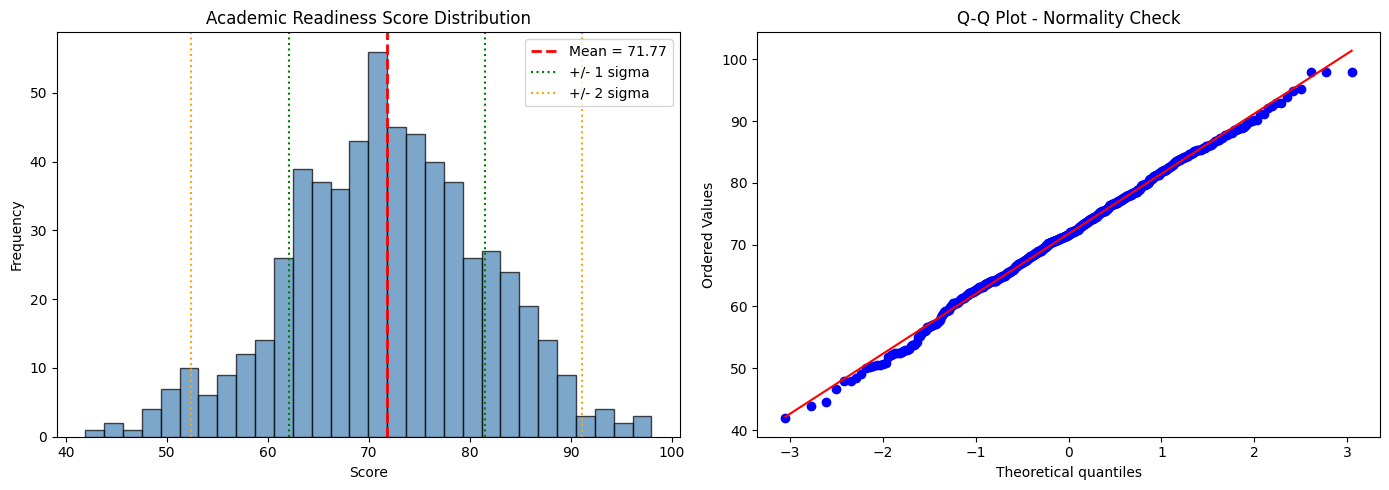

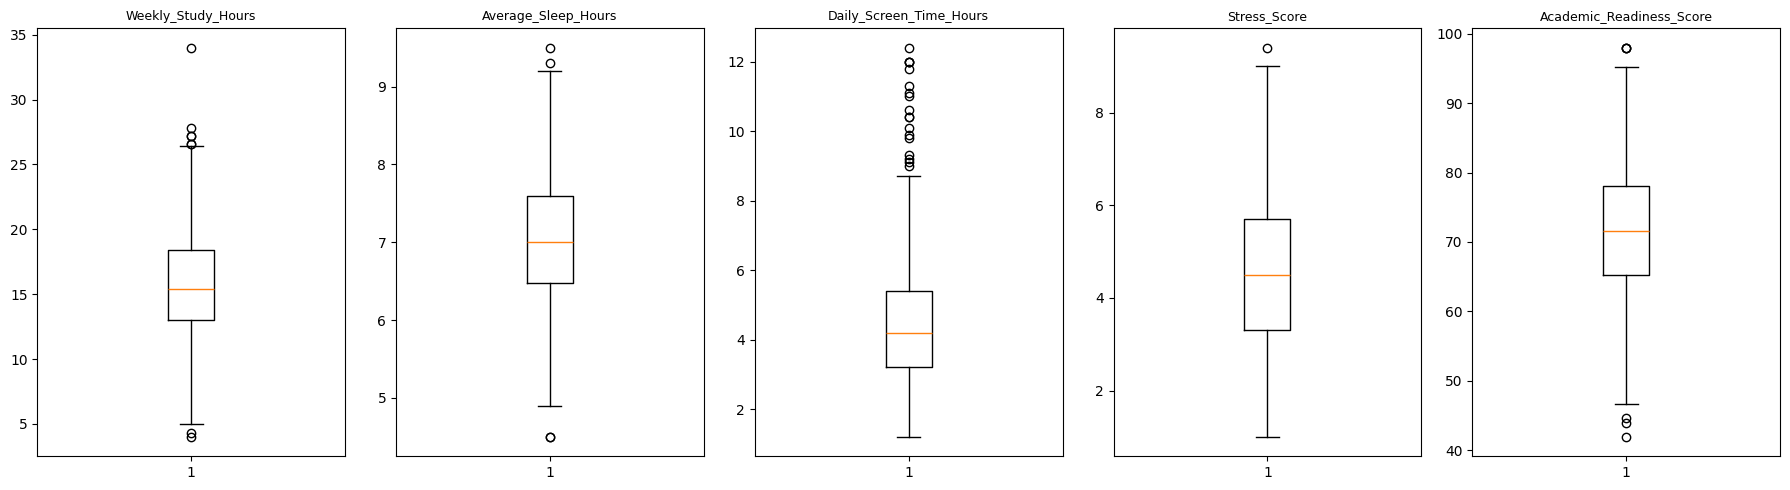

In [12]:
"""
Step 10: Visualizations and Key Observations
"""
import matplotlib.pyplot as plt
from scipy import stats
col = 'Academic_Readiness_Score'
mu = df[col].mean()
sigma = df[col].std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with sigma lines
axes[0].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(mu, color='red', linestyle='--', linewidth=2, label=f'Mean = {mu:.2f}')
axes[0].axvline(mu - sigma, color='green', linestyle=':', label='+/- 1 sigma')
axes[0].axvline(mu + sigma, color='green', linestyle=':')
axes[0].axvline(mu - 2*sigma, color='orange', linestyle=':', label='+/- 2 sigma')
axes[0].axvline(mu + 2*sigma, color='orange', linestyle=':')
axes[0].set_title('Academic Readiness Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Q-Q plot
stats.probplot(df[col], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot - Normality Check')

plt.tight_layout()
plt.show()

# Boxplots for all 5 analyzed variables
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
cols = ['Weekly_Study_Hours', 'Average_Sleep_Hours', 'Daily_Screen_Time_Hours',
        'Stress_Score', 'Academic_Readiness_Score']
for i, c in enumerate(cols):
    axes[i].boxplot(df[c])
    axes[i].set_title(c, fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
"""
Five Key Statistical Observations
"""
N = len(df)
A = df['Part_Time_Job'] == 'Yes'
B = df['Stress_Score'] >= 7

P_A = A.sum() / N
P_B = B.sum() / N
P_A_and_B = (A & B).sum() / N
product = P_A * P_B

cv = (df[['Weekly_Study_Hours','Average_Sleep_Hours','Daily_Screen_Time_Hours',
          'Stress_Score','Academic_Readiness_Score']].std() /
      df[['Weekly_Study_Hours','Average_Sleep_Hours','Daily_Screen_Time_Hours',
          'Stress_Score','Academic_Readiness_Score']].mean() * 100)

print(f"""
1. SCREEN TIME IS THE MOST VOLATILE METRIC
   Daily_Screen_Time_Hours has the highest Coefficient of Variation ({cv['Daily_Screen_Time_Hours']:.2f}%)
   compared to other variables, meaning students' screen habits vary
   far more than their study, sleep, or stress patterns.
   Range: {df['Daily_Screen_Time_Hours'].min()} to {df['Daily_Screen_Time_Hours'].max()} hrs/day.

2. HIGH STRESS IS A MINORITY BUT STRONGLY LINKED TO EMPLOYMENT
   Only {P_B*100:.1f}% of students report Stress >= 7.
   However, P(A and B) = {P_A_and_B:.4f} is 2.7x larger than P(A)*P(B) = {product:.4f}.
   This proves part-time jobs and high stress are NOT independent.

3. ACADEMIC READINESS IS ALMOST PERFECTLY NORMAL
   Mean = 71.77, Std = 9.69. Actual coverage matches the 68-95-99.7 rule
   within 1-2% (69.5%, 95.2%, 99.8%). Z-scores and parametric tests
   on this variable are reliable.

4. SPENDING IS HEAVILY RIGHT-SKEWED
   Monthly_Discretionary_Spending had 20 outliers (3.3%).
   Removing them dropped the mean by 370.06 but the median by only 95.00,
   confirming a small group of high spenders distorts the average.

5. BAYES' THEOREM CONFIRMS STRESS IS A STRONG SIGNAL FOR EMPLOYMENT
   P(B|A) = {P_B_given_A:.4f} vs P(B|not A) = {P_B_given_notA:.4f}.
   Working students are ~6.5x more likely to have high stress.
   Consequently, P(A|B) = 0.6889 means that among highly stressed students,
   nearly 7 in 10 have a part-time job.
""")


1. SCREEN TIME IS THE MOST VOLATILE METRIC
   Daily_Screen_Time_Hours has the highest Coefficient of Variation (41.36%)
   compared to other variables, meaning students' screen habits vary
   far more than their study, sleep, or stress patterns.
   Range: 1.2 to 12.4 hrs/day.

2. HIGH STRESS IS A MINORITY BUT STRONGLY LINKED TO EMPLOYMENT
   Only 7.5% of students report Stress >= 7.
   However, P(A and B) = 0.0517 is 2.7x larger than P(A)*P(B) = 0.0190.
   This proves part-time jobs and high stress are NOT independent.

3. ACADEMIC READINESS IS ALMOST PERFECTLY NORMAL
   Mean = 71.77, Std = 9.69. Actual coverage matches the 68-95-99.7 rule
   within 1-2% (69.5%, 95.2%, 99.8%). Z-scores and parametric tests
   on this variable are reliable.

4. SPENDING IS HEAVILY RIGHT-SKEWED
   Monthly_Discretionary_Spending had 20 outliers (3.3%).
   Removing them dropped the mean by 370.06 but the median by only 95.00,
   confirming a small group of high spenders distorts the average.

5. BAYES' TH